# Access Urban Heat MiniCubes through the NCAR GDEX
Author: Jonathan Starfeldt

## Required Packages
Please make sure to installed the packages before moving forward
- matplotlib
- xarray
- numpy
- scipy
- pillow
- statsmodels

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import glob
from datetime import datetime, timedelta
from scipy import stats
from scipy.ndimage import gaussian_filter
from PIL import Image
from statsmodels.nonparametric.kde import KDEUnivariate

## Step 1 - Research Question
If we filter and downscale land surface temperature data from the high-resolution modality to match the resolution of the low-resolution modality brightness temperatures, will the spatial variabilities of the two temperature variables be equivalent?

## Step 2 - Locate the Dataset
On the NCAR GDEX portal, go to the `Data Access` tab for the Urban Heat MiniCubes dataset to find the intake-ESM catalogs needed to access data. In this notebook we will use GDEX POSIX catalog.

In [2]:
data_posix_path = '/gdex/data/d539393'

## Step 3 - Open the Data

In [3]:
high_res_files = sorted(glob.glob(f'{data_posix_path}/high_resolution/data/*'))
high_res_files[:5]

['/gdex/data/d539393/high_resolution/data/hresgrid_CYUL_202201251538.nc',
 '/gdex/data/d539393/high_resolution/data/hresgrid_CYUL_202202181538.nc',
 '/gdex/data/d539393/high_resolution/data/hresgrid_CYUL_202202261538.nc',
 '/gdex/data/d539393/high_resolution/data/hresgrid_CYUL_202203221538.nc',
 '/gdex/data/d539393/high_resolution/data/hresgrid_CYUL_202203301538.nc']

In [4]:
low_res_files = sorted(glob.glob(f'{data_posix_path}/low_resolution/data/*'))
low_res_files[:5]

['/gdex/data/d539393/low_resolution/data/lresgrid_CYUL.nc',
 '/gdex/data/d539393/low_resolution/data/lresgrid_CYYZ.nc',
 '/gdex/data/d539393/low_resolution/data/lresgrid_KATL.nc',
 '/gdex/data/d539393/low_resolution/data/lresgrid_KBIL.nc',
 '/gdex/data/d539393/low_resolution/data/lresgrid_KBWI.nc']

In [5]:
ds_highres = xr.open_dataset(high_res_files[0])
ds_highres

<xarray.Dataset> Size: 936MB
Dimensions:                        (y: 3000, x: 3000)
Coordinates:
  * x                              (x) float64 24kB 5.641e+05 ... 6.54e+05
  * y                              (y) float64 24kB 4.999e+06 ... 5.089e+06
    datetime                       object 8B ...
Data variables: (12/14)
    Landsat_cloud_mask             (y, x) object 72MB ...
    Landsat_blue_sfc_reflectance   (y, x) float64 72MB ...
    Landsat_green_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_red_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_NIR_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_SWIR1_sfc_reflectance  (y, x) float64 72MB ...
    ...                             ...
    Sentinel1_VV                   (y, x) float64 72MB ...
    Sentinel1_VH                   (y, x) float64 72MB ...
    Sentinel1_HH                   (y, x) float64 72MB ...
    Sentinel1_HV                   (y, x) float64 72MB ...
    Sentinel1_incidence_angle      (y, x) float64 72MB ...
    spatial_ref                    int32 4B ...
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    title:          Landsat 9 and Sentinel-1 data for Montreal, Quebec, Canada
    institution:    University of Maryland, College Park
    source:         Satellite observation

In [6]:
ds_lowres = xr.open_dataset(low_res_files[0])
ds_lowres

<xarray.Dataset> Size: 8GB
Dimensions:        (time: 104730, y: 45, x: 45)
Coordinates:
    datetime       (time) <U20 8MB ...
  * x              (x) float64 360B 5.65e+05 5.67e+05 ... 6.51e+05 6.53e+05
  * y              (y) float64 360B 5.001e+06 5.003e+06 ... 5.087e+06 5.089e+06
  * time           (time) datetime64[ns] 838kB 2022-01-01 ... 2023-12-31T23:5...
Data variables:
    GOES_C13_LWIR  (time, y, x) float64 2GB ...
    GOES_C14_LWIR  (time, y, x) float64 2GB ...
    GOES_C15_LWIR  (time, y, x) float64 2GB ...
    GOES_C16_LWIR  (time, y, x) float64 2GB ...
    microwave_LST  (time, y, x) float64 2GB ...
    spatial_ref    (time) int32 419kB ...
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    title:          GOES-16 and microwave LST data for Montreal, Quebec, Canada
    institution:    University of Maryland, College Park
    source:         Satellite observation

Find the timestep from the lowres file that overlaps with the highres file.

In [7]:
dt = ds_highres['datetime'].values
dt

array('2022-01-25T15:38:33Z', dtype=object)

In [8]:
format_str = "%Y-%m-%dT%H:%M:%SZ"
dt = datetime.strptime(dt.item(), format_str)
dt

datetime.datetime(2022, 1, 25, 15, 38, 33)

In [9]:
ds_lowres_overlapping_t = ds_lowres.sel(time=dt, method='nearest')
ds_lowres_overlapping_t

<xarray.Dataset> Size: 82kB
Dimensions:        (y: 45, x: 45)
Coordinates:
    datetime       <U20 80B ...
  * x              (x) float64 360B 5.65e+05 5.67e+05 ... 6.51e+05 6.53e+05
  * y              (y) float64 360B 5.001e+06 5.003e+06 ... 5.087e+06 5.089e+06
    time           datetime64[ns] 8B 2022-01-25T15:40:00
Data variables:
    GOES_C13_LWIR  (y, x) float64 16kB ...
    GOES_C14_LWIR  (y, x) float64 16kB ...
    GOES_C15_LWIR  (y, x) float64 16kB ...
    GOES_C16_LWIR  (y, x) float64 16kB ...
    microwave_LST  (y, x) float64 16kB ...
    spatial_ref    int32 4B ...
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    title:          GOES-16 and microwave LST data for Montreal, Quebec, Canada
    institution:    University of Maryland, College Park
    source:         Satellite observation

## Step 4 - Focus on the Variable addressing the Research Question
We will be looking at GOES band 14 brightness temperature and Landsat land surface temperature (LST).

Text(0, 0.5, 'Y Index')

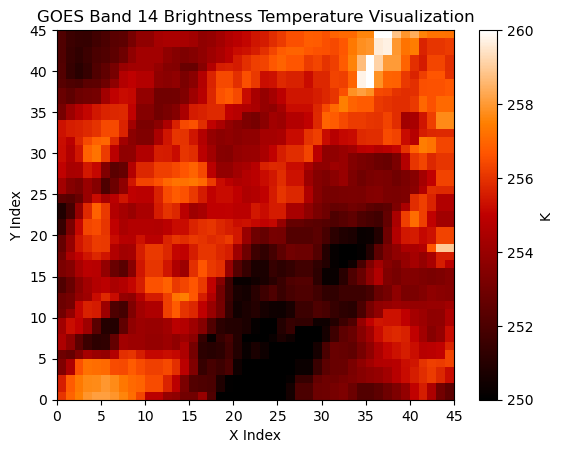

In [10]:
cb = plt.pcolormesh(ds_lowres_overlapping_t['GOES_C14_LWIR'], cmap='gist_heat', vmin=250, vmax=260)
plt.colorbar(cb, label='K')
plt.title('GOES Band 14 Brightness Temperature Visualization')
plt.xlabel('X Index')
plt.ylabel('Y Index')

Text(0, 0.5, 'Y Index')

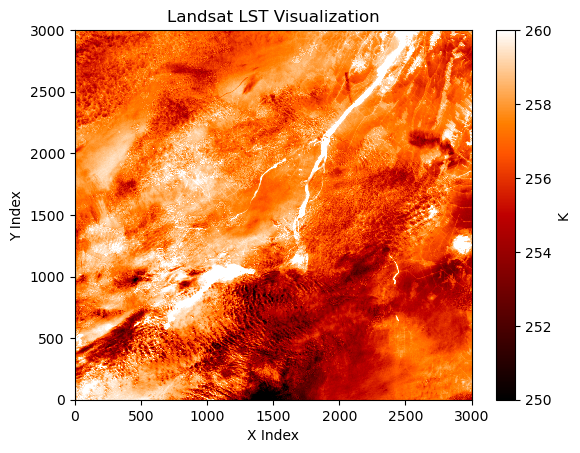

In [11]:
cb = plt.pcolormesh(ds_highres['Landsat_LST'], cmap='gist_heat', vmin=250, vmax=260)
plt.colorbar(cb, label='K')
plt.title('Landsat LST Visualization')
plt.xlabel('X Index')
plt.ylabel('Y Index')

Now, let's see what happens when we filter and coarsen a Landsat LST image

Text(0, 0.5, 'Y Index')

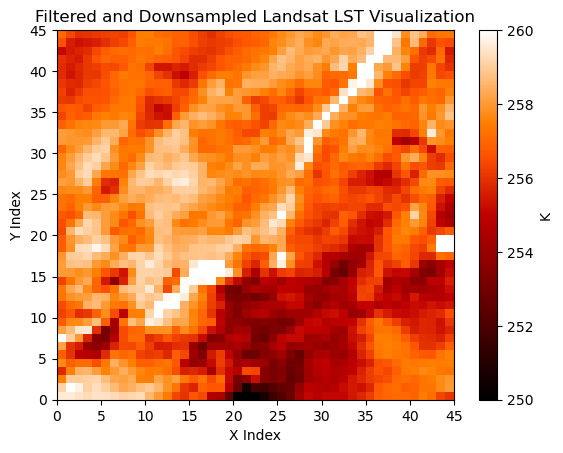

In [12]:
filtered = gaussian_filter(ds_highres['Landsat_LST'], sigma=3)
resized = np.array(Image.fromarray(filtered).resize((45, 45)))

cb = plt.pcolormesh(resized, cmap='gist_heat', vmin=250, vmax=260)
plt.colorbar(cb, label='K')
plt.title('Filtered and Downsampled Landsat LST Visualization')
plt.xlabel('X Index')
plt.ylabel('Y Index')

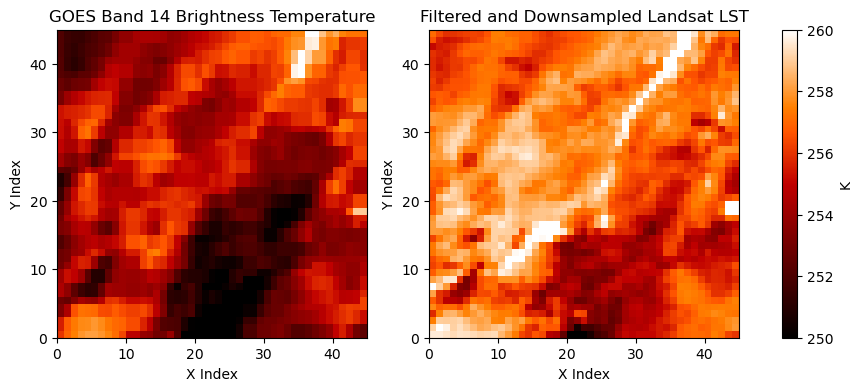

In [13]:
# Compare the two side-by-side
fig, axs = plt.subplots(1, 2)
fig.set_size_inches(11, 4)

axs[0].pcolormesh(ds_lowres_overlapping_t['GOES_C14_LWIR'], cmap='gist_heat', vmin=250, vmax=260)
axs[0].set_title('GOES Band 14 Brightness Temperature')
axs[0].set_xlabel('X Index')
axs[0].set_ylabel('Y Index')
axs[0].set_yticks(np.arange(0, 41, 10))

cb = axs[1].pcolormesh(resized, cmap='gist_heat', vmin=250, vmax=260)
axs[1].set_title('Filtered and Downsampled Landsat LST')
axs[1].set_xlabel('X Index')
axs[1].set_ylabel('Y Index')
axs[1].set_yticks(np.arange(0, 41, 10))

plt.colorbar(cb, label='K', ax=axs, location='right')

## Step 5 - Data Analysis

In [14]:
# Dictionary mapping city names or abbreviations to full
# city and country information
city_str_dict = {
    'KATL': 'Atlanta, Georgia, USA',
    'KBIL': 'Billings, Montana, USA',
    'SKBO': 'Bogota, Colombia',
    'SBBR': 'Brasilia, Brazil',
    'SAEZ': 'Buenos Aires, Argentina',
    'MMUN': 'Cancun, Mexico',
    'SVMI': 'Caracas, Venezuela',
    'KCLT': 'Charlotte, North \nCarolina, USA',
    'KORD': 'Chicago, Illinois, USA',
    'KDFW': 'Dallas, Texas, USA and \nFort Worth, Texas, USA',
    'KDEN': 'Denver, Colorado, USA',
    'MMGL': 'Guadalajara, Mexico',
    'MGGT': 'Guatemala City, \nGuatemala',
    'MUHA': 'Havana, Cuba',
    'KIAH': 'Houston, Texas, USA',
    'KJAX': 'Jacksonville, Florida, USA',
    'SLLP': 'La Paz, Bolivia',
    'KLAS': 'Las Vegas, \nNevada, USA',
    'SPJC': 'Lima, Peru',
    'KLAX': 'Los Angeles, \nCalifornia, USA',
    'MNMG': 'Managua, Nicaragua',
    'SBEG': 'Manaus, Brazil',
    'MMMX': 'Mexico City, Mexico',
    'KMIA': 'Miami, Florida, USA',
    'KMSP': 'Minneapolis, \nMinnesota, USA',
    'MMMY': 'Monterrey, Mexico',
    'SUMU': 'Montevideo, Uruguay',
    'CYUL': 'Montreal, \nQuebec, Canada',
    'KMSY': 'New Orleans, \nLouisiana, USA',
    'KJFK': 'New York City, \nNew York, USA',
    'MPTO': 'Panama City, Panama',
    'KPHL': 'Philadelphia, \nPennsylvania, USA',
    'KPHX': 'Phoenix, Arizona, USA',
    'SCCI': 'Punta Arenas, Chile',
    'SEQM': 'Quito, Ecuador',
    'KSLC': 'Salt Lake City, \nUtah, USA',
    'KSAN': 'San Diego, California, USA \nand Tijuana, Mexico',
    'KSFO': 'San Francisco, \nCalifornia, USA',
    'MROC': 'San Jose, Costa Rica',
    'TJSJ': 'San Juan, Puerto Rico',
    'SCEL': 'Santiago, Chile',
    'MDSD': 'Santo Domingo, \nDominican Republic',
    'SBGR': 'Sao Paulo, Brazil',
    'KSEA': 'Seattle, \nWashington, USA',
    'KSTL': 'St Louis, Missouri, USA',
    'MHTG': 'Tegucigalpa, Honduras',
    'CYYZ': 'Toronto, Ontario, Canada',
    'KBWI': 'Washington, DC, USA and \nBaltimore, Maryland, USA'
}
cities = list(city_str_dict.keys())

In [15]:
def round_to_nearest_10_minutes(dt):
    """
    Rounds a datetime object to the nearest 10 minutes.

    Args:
    dt (datetime object): Datetime to round

    Returns:
    rounded_dt (datetime object): Rounded datetime
    """
    # Calculate the remainder when minutes are divided by 10
    remainder_minutes = dt.minute % 10

    # Determine whether to round up or down
    if remainder_minutes >= 5:
        # Round up: add minutes to reach the next 10-minute interval
        minutes_to_add = 10 - remainder_minutes
        rounded_dt = dt + timedelta(minutes=minutes_to_add)
    else:
        # Round down: subtract minutes to reach the previous 10-minute interval
        minutes_to_subtract = remainder_minutes
        rounded_dt = dt - timedelta(minutes=minutes_to_subtract)

    return rounded_dt

In [16]:
def round_time_str(dt_str):
    """
    Converts a datetime string from a data file to a
    datetime object and rounds it to the nearest 10 minutes.

    Args:
    dt_str (str): Datetime string to round

    Returns:
    rounded_dt (datetime object): Rounded datetime
    """
    format_string = "%Y-%m-%dT%H:%M:%SZ"
    dt = datetime.strptime(dt_str, format_string)
    rounded_dt = round_to_nearest_10_minutes(dt)

    return rounded_dt

In [17]:
# For each processed Landsat file, adds the closest GOES file in time
# to the GOES_date_dict object, if it exists
format_string = "%Y%m%d%H%M"
GOES_date_dict = {string: [] for string in cities}  # GOES datetimes at Landsat file datetimes

for city in cities:
    city_highres_list = [x for x in high_res_files if city in x]
    city_lowres_file = [x for x in low_res_files if city in x][0]
    #ds_city_lowres = xr.open_dataset(city_lowres_file)
    #city_lowres_dts = ds_city_lowres['time'].values.astype('datetime64[m]')

    for file in city_highres_list:
        dt_str = file.split('_')[-1].split('.')[0]
        dt = datetime.strptime(dt_str, format_string)
        rounded_dt = round_to_nearest_10_minutes(dt)
        GOES_date_dict[city].append(rounded_dt)
    #GOES_date_dict[city] = [x for x in GOES_date_dict[city] if x in city_lowres_dts]  # Filtering out time without GOES observations

In [18]:
def get_GOES_vars(city):
    """
    Calculates the spatial standard deviation of GOES BT band 14
    in each GOES/MW LST file for a given city.

    Args:
    city (str): city from the 'cities' list

    Returns:
    GOES_vars (np.array): Array of spatial standard deviations of
                          GOES BTs. Will be of shape (n, 4), where n
                          is the number of GOES files in the given city
    """
    GOES_vars = []
    city_file = [x for x in low_res_files if city in x][0]
    ds = xr.open_dataset(city_file)
    lowres_dts = ds['time'].values.astype('datetime64[m]')
    filtered_dts = [x for x in GOES_date_dict[city] if x in lowres_dts]  # Filtering out time without GOES observations
    ds_Landsat_times = ds.sel(time=filtered_dts)

    GOES_vars = np.nanstd(ds_Landsat_times['GOES_C14_LWIR'], axis=(1, 2))

    return GOES_vars

In [19]:
def get_filtered_Landsat_vars(city):
    """
    For each Landsat/Sentinel-1 image for a given city,
    apply a Gaussian filter to Landsat LST and resize
    the image to GOES dimensions (45x45) with bicubic resampling.
    Then, calculate the spatial standard deviation of the
    resized image.

    Args:
    city (str): city from the 'cities' list

    Returns:
    Landsat_vars (list): List of spatial standard deviations of
                         filtered and resized Landsat LST. Will be of
                         length n, where n is the number of Landsat/Sentinel-1
                         files in the given city
    """
    Landsat_vars = []
    city_list = [x for x in high_res_files if city in x]

    for file in city_list:
        ds = xr.open_dataset(file)
        filtered = gaussian_filter(ds['Landsat_LST'], sigma=3)
        resized = np.array(Image.fromarray(filtered).resize((45, 45)))
        Landsat_vars.append(np.nanstd(resized))
    return Landsat_vars

/glade/work/jstarfeldt/conda-envs/heat/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


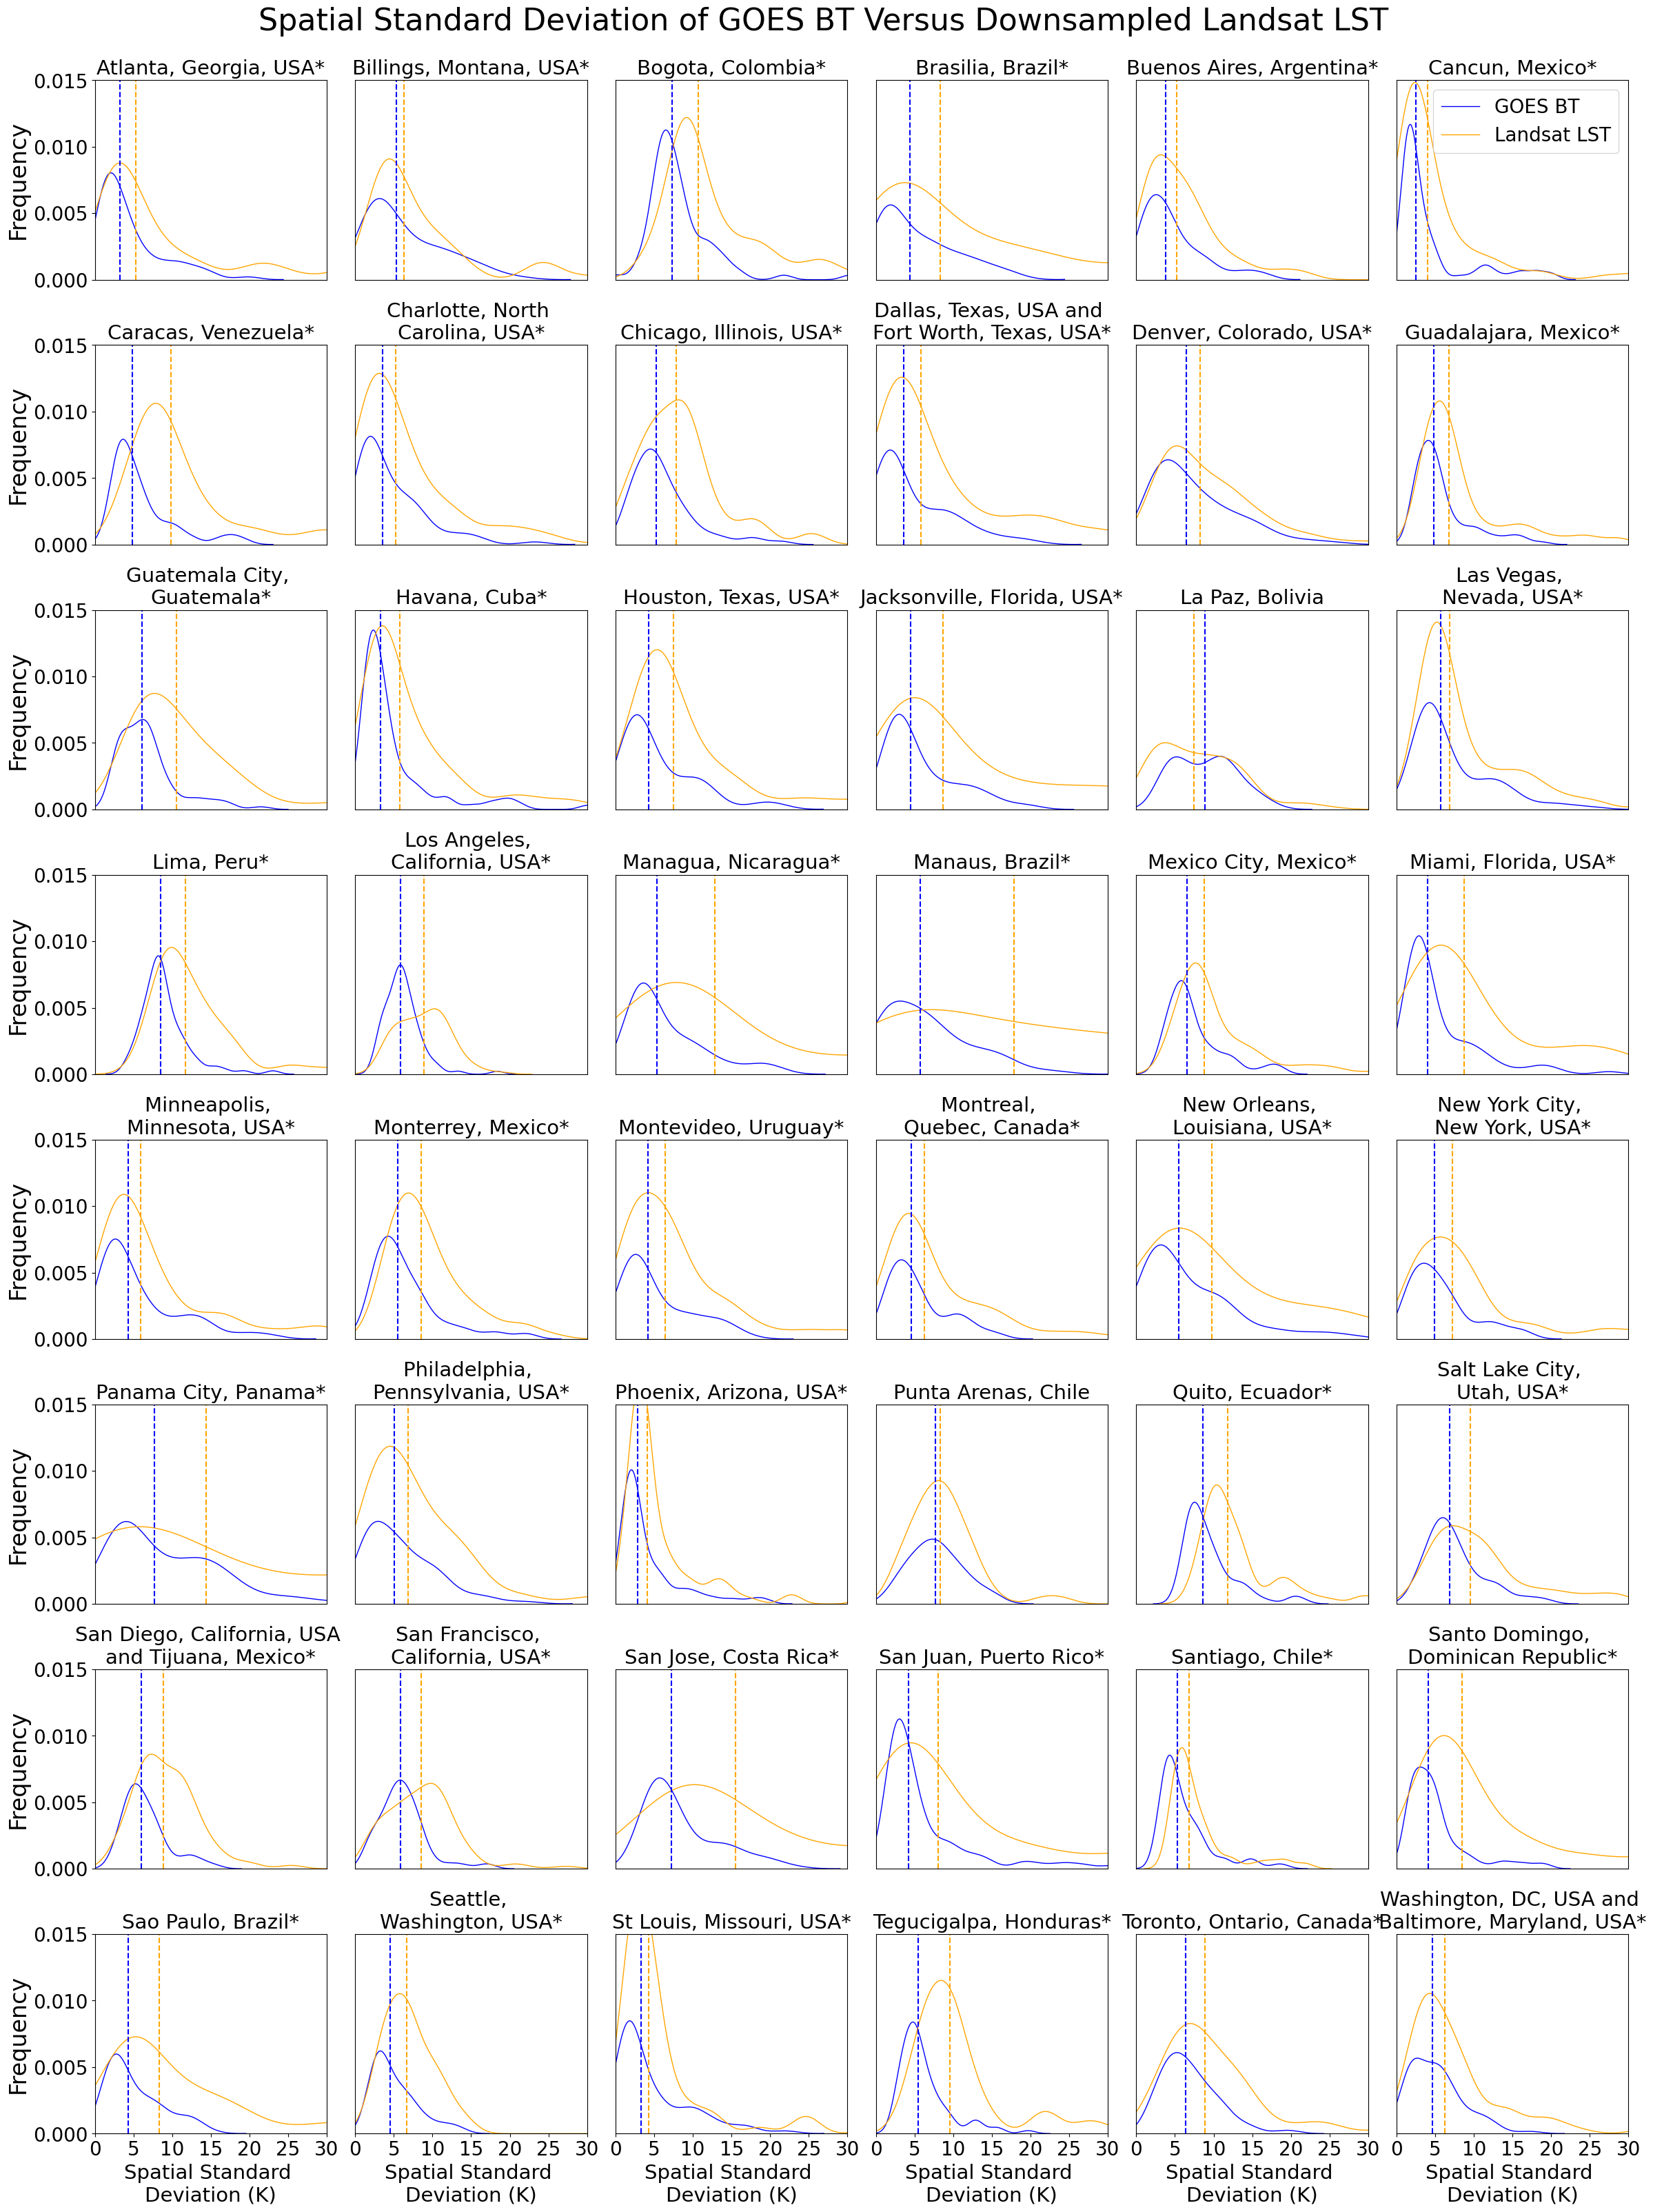

In [20]:
# NOTE: This will take a while (~1.5 hours) to run

# Set up plot axes and general variables
fig, axs = plt.subplots(8, 6)
fig.set_size_inches(24, 32)
plt.subplots_adjust(hspace=0.2)

for i in range(8):
    for j in range(6):
        city = cities[i*6+j]

        # Get GOES BT spatial standard deviations and fit a PDF
        GOES_data = get_GOES_vars(city)
        GOES_pdf = KDEUnivariate(GOES_data)
        GOES_pdf.fit()
        BT_std = GOES_pdf.density/np.sum(GOES_pdf.density)

        # Get Landsat LST spatial standard deviations and fit a PDF
        Landsat_data = np.array(get_filtered_Landsat_vars(city))
        Landsat_pdf = KDEUnivariate(Landsat_data[~np.isnan(Landsat_data)])
        Landsat_pdf.fit()
        LST_std = Landsat_pdf.density/np.sum(Landsat_pdf.density)

        # Calculate Mann-Whitney U test for equivalence of distribution
        p_value = stats.mannwhitneyu(Landsat_data, GOES_data, alternative='greater', nan_policy='omit').pvalue

        # Plot both PDFs
        axs[i, j].plot(GOES_pdf.support, BT_std, color='b', linewidth=1, label='GOES BT')
        axs[i, j].plot(Landsat_pdf.support, LST_std, color='orange', linewidth=1, label='Landsat LST')

        # Calculate the midpoint of both distributions
        # and plot them as dashed vertical lines
        Landsat_middle = Landsat_pdf.support[np.where(Landsat_pdf.cdf >= 0.5)[0][0]]
        GOES_middle = GOES_pdf.support[np.where(GOES_pdf.cdf >= 0.5)[0][0]]
        axs[i, j].axvline(x=Landsat_middle, color='orange', linestyle='--')
        axs[i, j].axvline(x=GOES_middle, color='b', linestyle='--')

        # Set axis title, with an asterisk if p < 0.05
        if p_value < 0.05:
            axs[i, j].set_title(city_str_dict[city]+'*', fontsize=21)
        else:
            axs[i, j].set_title(city_str_dict[city], fontsize=21)

        # Format y-axis ticks to 3 decimal places
        formatter_y = mticker.StrMethodFormatter("{x:.3f}")
        axs[i, j].yaxis.set_major_formatter(formatter_y)
        axs[i, j].set_xlim(left=0, right=30)
        axs[i, j].set_xticks([])
        axs[i, j].set_ylim(bottom=0, top=0.015)
        axs[i, j].set_yticks([])

        # Set axis ticks and labels for the left and bottom edges
        if j == 0:
            axs[i, j].set_ylabel('Frequency', fontsize=24)
            axs[i, j].set_yticks(np.arange(0, 0.016, 0.005))
            axs[i, j].tick_params(axis='y', labelsize=20)
        if i == 7:
            axs[i, j].set_xlabel('Spatial Standard \nDeviation (K)', fontsize=21)
            axs[i, j].set_xticks(np.arange(0, 31, 5))
            axs[i, j].tick_params(axis='x', labelsize=20)

# Add a legend
handles, labels = axs[0, 0].get_legend_handles_labels()
axs[0, 5].legend(handles, labels, fontsize=20, loc='upper right')

# Set a title and save the figure
plt.suptitle('Spatial Standard Deviation of GOES BT Versus Downsampled Landsat LST', y=1.001, fontsize=32)
plt.tight_layout()